# Gridding methods

## ArgoPy dataset

In [1]:
import numpy as np
import pandas as pd
from argopy import DataFetcher 

north, west, south, east = 90, -180, 0, 180

# Fetch real data once for the whole period
fetcher = DataFetcher().region([west, east, south, north, 0, 50, "2024-01-01", "2024-01-02"])
df = fetcher.to_dataframe()
# df = df.dropna(subset=["TEMP", "LATITUDE", "LONGITUDE"])

Text(0, 0.5, 'Latitude')

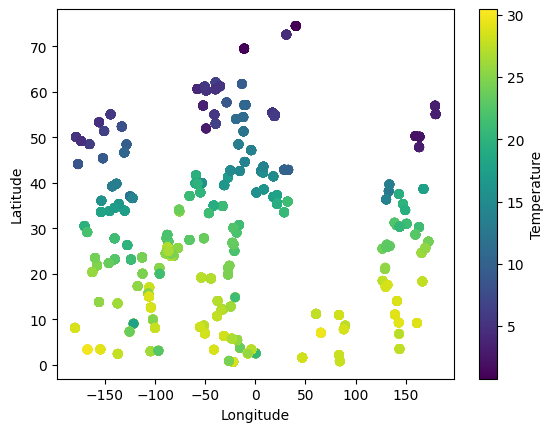

In [2]:
# plot this data to check it looks reasonable
import matplotlib.pyplot as plt
plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['TEMP'], cmap='viridis')
plt.colorbar(label='Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [3]:
# Grid setup
lats = np.arange(south + 0.5, north + 0.5, 2)
lons = np.arange(west + 0.5, east + 0.5, 2)
n_lat = len(lats)
n_lon = len(lons)
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
times = pd.to_datetime(["2024-01-01", "2024-01-02"]).to_pydatetime().tolist()
temp_data = np.full((len(times), len(lats), len(lons)), np.nan, dtype=float)


### Nested loop

In [4]:
for t_idx, date in enumerate(times):
    sigma = 200

    for lat_idx, lat in enumerate(lats):
        for lon_idx, lon in enumerate(lons):
            # logging.info(f"Processing grid cell at lat: {lat}, lon: {lon}")
            t_weighted, sum_weights = 0, 0
            for row in df.itertuples():
                
                obs_lat = row.LATITUDE
                obs_lon = row.LONGITUDE
                obs_temp = row.TEMP

                from haversine import Unit, haversine

                obs_point = (obs_lat, obs_lon)  # shape: (n_obs, 2)
                grid_point = (lat, lon)  # shape: (n_lat*n_lon, 2)
                
                # Pairwise distances in km: shape (n_obs, n_lat*n_lon)
                distance_km = haversine(
                    obs_point,
                    grid_point,
                    unit=Unit.KILOMETERS,
                    )
                distance2 = distance_km ** 2# calculate the weighted distcance
                weight = np.exp(-0.5 * distance2 / sigma**2)
                t_weighted += weight * row.TEMP
                sum_weights += weight
            # print (f"weights: {weight}  sum_weights: {sum_weights}, t_weighted: {t_weighted}")
            temp_data[t_idx, lat_idx, lon_idx] = t_weighted / sum_weights

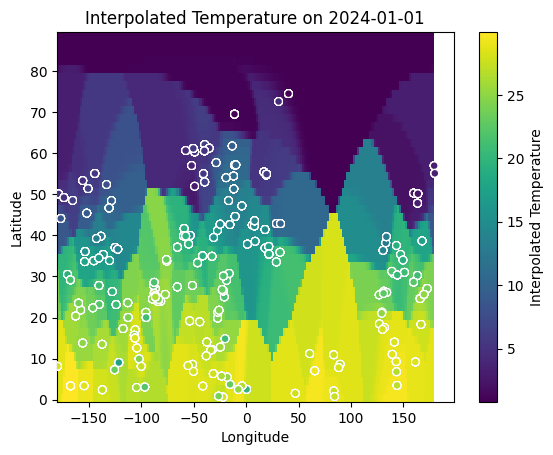

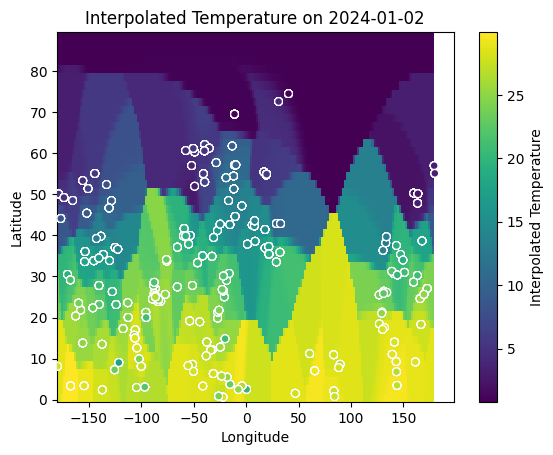

In [5]:
for t_idx, date in enumerate(times):
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

### 1st Haversine method

In [6]:
from haversine import Unit, haversine_vector
import numpy as np

sigma = 200

# Creates a list of (lat, lon) tuples 
obs_points = list(zip(df['LATITUDE'], df['LONGITUDE']))
obs_temps = df['TEMP'].values
n_obs = len(obs_points)

# Build flat grid
# Flattens the 2D output grid into a 1D list of (lat, lon) tuples
grid_points = [(lat, lon) for lat in lats for lon in lons]
n_grid = len(grid_points)

for t_idx, date in enumerate(times):
    # Compute the distance from every obs station to every grid point (an (n_grid × n_obs) matrix) in one call.
    # Compute all obs→grid distances: shape (n_obs * n_grid,)
    # haversine_vector expects two equal-length lists
    obs_repeated = obs_points * n_grid          # each obs point repeated n_grid times
    grid_tiled = [gp for gp in grid_points for _ in range(n_obs)]  # each grid point repeated n_obs times

    distance_km = haversine_vector(
        obs_repeated,
        grid_tiled,
        unit=Unit.KILOMETERS,
    ).reshape(n_grid, n_obs)  # shape: (n_grid, n_obs)

    weights = np.exp(-0.5 * (distance_km / sigma) ** 2)  # (n_grid, n_obs)
    t_weighted = (weights * obs_temps).sum(axis=1)        # (n_grid,)
    sum_weights = weights.sum(axis=1)                     # (n_grid,)

    temp_data[t_idx] = (t_weighted / sum_weights).reshape(len(lats), len(lons))

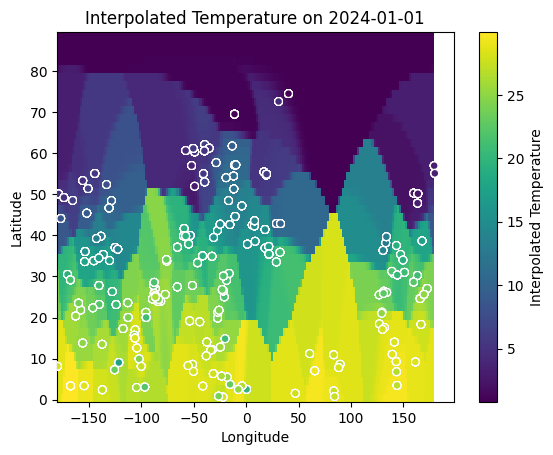

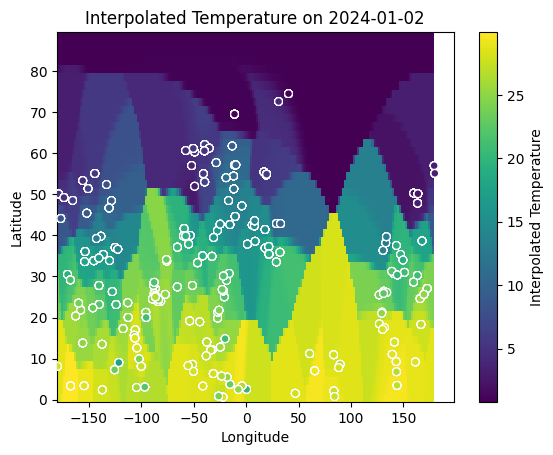

In [7]:
# plot the grid data for each day separately
for t_idx, date in enumerate(times):
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

### 2nd Haversine method


In [8]:
from haversine import Unit, haversine_vector
sigma = 200
min_weight = 1e-10

obs_lat = df["LATITUDE"].to_numpy(dtype=float)
obs_lon = df["LONGITUDE"].to_numpy(dtype=float)
obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)
    
for t_idx, date in enumerate(times):
    # Get positions of observations
    # Pairwise distances in km
    distance_km: np.ndarray = haversine_vector(
        obs_points,
        grid_points,
        unit=Unit.KILOMETERS,
        comb=True,
        check=False,  # faster if your lat/lon are already valid
    )  # shape: (n_lat*n_lon, n_obs)

    # Construct exponential weights, with a minimum for numerical stability
    weights = np.exp(-0.5 * (distance_km / sigma) ** 2) #.clip(
    #     min=min_weight
    # )  # shape: (n_lat*n_lon, n_obs)
    sum_weights = np.sum(weights, axis=1)  # shape: (n_lat*n_lon,)

    # Apply weights to the data
    # for variable, weighted_array in weighted_data.items():
    unweighted_data = df['TEMP'].to_numpy(dtype=float)
    temp_data[t_idx] = (
        np.matmul(weights, unweighted_data) / sum_weights
    ).reshape(1, len(lats), len(lons))  # shape: (n_lat*n_lon,)

print(f"temp_data: {temp_data}")

temp_data: [[[28.67030824 28.67142174 29.52141359 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030777 28.6703674  28.78952706 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030775 28.67031098 28.67725187 ... 28.67030775 28.67030775
   28.67030775]
  ...
  [ 0.80147978  0.80147982  0.80147987 ...  0.80147968  0.80147971
    0.80147974]
  [ 0.80148341  0.8014836   0.80148382 ...  0.80148298  0.8014831
    0.80148324]
  [ 0.80150849  0.80150905  0.80150967 ...  0.80150718  0.80150756
    0.801508  ]]

 [[28.67030824 28.67142174 29.52141359 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030777 28.6703674  28.78952706 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030775 28.67031098 28.67725187 ... 28.67030775 28.67030775
   28.67030775]
  ...
  [ 0.80147978  0.80147982  0.80147987 ...  0.80147968  0.80147971
    0.80147974]
  [ 0.80148341  0.8014836   0.80148382 ...  0.80148298  0.8014831
    0.80148324]
  [ 0.80150849  0.80150905  0.80150967 ...  0.80150718  0.801507

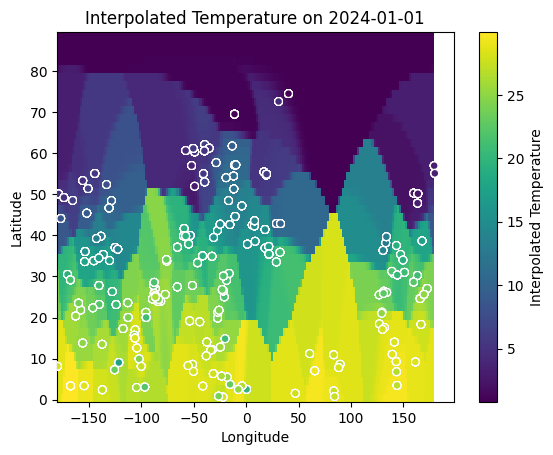

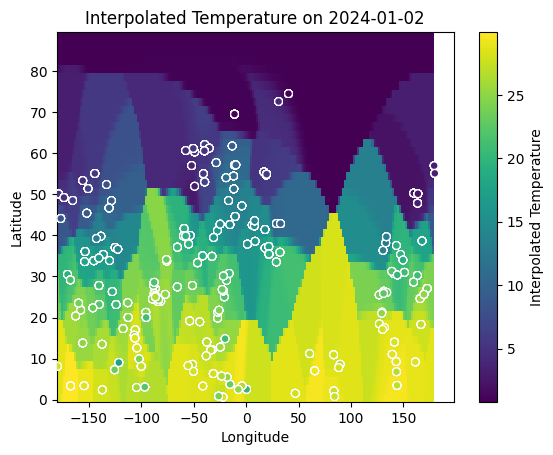

In [9]:
for t_idx, date in enumerate(times):
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

## Full argo script


In [ ]:
from datetime import datetime, timedelta
import xarray as xr

north, west, south, east = 90, -180, 0, 180
grid_resolution_degrees = 1
times = pd.to_datetime(["2017-01-18", "2017-01-19"]).to_pydatetime().tolist()

# Set constants
distance_scale_km = 2000
# min_weight = 1e-10

# Construct the grid that we want to project onto
lats = np.arange(
    south + 0.5 * grid_resolution_degrees,
    north + 0.5 * grid_resolution_degrees,
    grid_resolution_degrees,
)
lons = np.arange(
    west + 0.5 * grid_resolution_degrees,
    east + 0.5 * grid_resolution_degrees,
    grid_resolution_degrees,
)

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

requested_dates = sorted(times)  # sorted(date_group.dates)
weighted_data: dict[str, np.ndarray] = {
    variable: np.full(
        (len(requested_dates), len(lats), len(lons)), np.nan, dtype=float
    )
    for variable in ["TEMP", "PSAL"] 
}
# save the output dataframes to a list
output_dataframes = []

for t_idx, date in enumerate(requested_dates):
    start_time = date - timedelta(hours=1)
    end_time = date + timedelta(hours=1)

    # Extract data for the mixed layer (top 50m), retry if 503 error from erddap
    region = [west, east, south, north, 0, 50, start_time, end_time]
    fetcher = DataFetcher().region([west, east, south, north, 0, 50, start_time, end_time])
    dataframe = fetcher.to_dataframe()

    # Get positions of observations
    obs_lat = dataframe["LATITUDE"].to_numpy(dtype=float)
    obs_lon = dataframe["LONGITUDE"].to_numpy(dtype=float)
    obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)

    # Pairwise distances in km
    distance_km: np.ndarray = haversine_vector(
        obs_points,
        grid_points,
        unit=Unit.KILOMETERS,
        comb=True,
        check=False,  # faster if your lat/lon are already valid
    )  # shape: (n_lat*n_lon, n_obs)

    # Construct exponential weights, with a minimum for numerical stability
    weights = np.exp(-0.5 * (distance_km / distance_scale_km) ** 2).clip(
        min=min_weight
    )  # shape: (n_lat*n_lon, n_obs)
    sum_weights = np.sum(weights, axis=1)  # shape: (n_lat*n_lon,)

    # Apply weights to the data
    for variable, weighted_array in weighted_data.items():
        unweighted_data = dataframe[variable].to_numpy(dtype=float)
        weighted_array[t_idx] = (
            np.matmul(weights, unweighted_data) / sum_weights
        ).reshape(1, len(lats), len(lons))  # shape: (n_lat*n_lon,)
    output_dataframes.append(dataframe)

# Construct an xarray dataset
ds_out = xr.Dataset(
    data_vars={
        variable: (
            ("time", "lat", "lon"),
            data_array,
            {"coordinates": "time lat lon"},
        )
        for variable, data_array in weighted_data.items()
    },
    coords={
        "time": (
            "time",
            np.asarray(requested_dates, dtype="datetime64[ns]"),
            {
                "standard_name": "time",
                "units": "seconds since 1970-01-01 00:00:00",
                "calendar": "standard",
            },
        ),
        "lat": (
            "lat",
            lats,
            {
                "standard_name": "latitude",
                "units": "degrees_north",
            },
        ),
        "lon": (
            "lon",
            lons,
            {
                "standard_name": "longitude",
                "units": "degrees_east",
            },
        ),
    },
)

In [28]:
times

[datetime.datetime(2017, 1, 18, 0, 0), datetime.datetime(2017, 1, 19, 0, 0)]

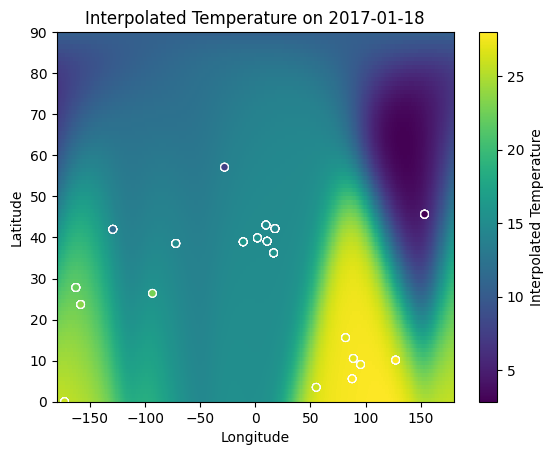

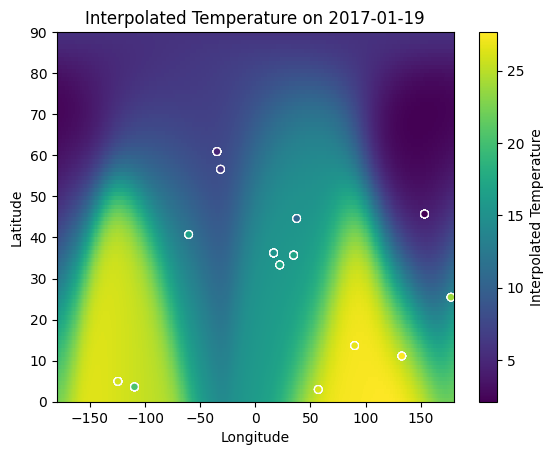

In [29]:
for t_idx, date in enumerate(times):
    dataframe = output_dataframes[t_idx]
    plt.figure()
    plt.pcolormesh(ds_out["lon"], ds_out["lat"], ds_out["TEMP"][t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(dataframe['LONGITUDE'], dataframe['LATITUDE'], c=dataframe['TEMP'], cmap='viridis',
        edgecolors='white', linewidths=0.8, s=30, zorder=5)
    

# Accessing ARGO data

Initially working from the summary sheet: https://argopy.readthedocs.io/en/latest/_static/argopy-cheatsheet.pdf


In [12]:
# Download a dataset based on longitude, latitude, pressure and time range
fetcher = DataFetcher().region([-75, -45, 20, 30, 0, 100, '2026-02', '2026-04'])

In [13]:
# Alternatively download specific float profiles
fetcher1 = DataFetcher().float([6902746, 6902755])

In [14]:
# Or specific cycles of a given float
fetcher2 = DataFetcher().profile(6902746, [1,12])

In [15]:
# convert to xarray
fetcher.to_xarray()

<xarray.Dataset> Size: 2MB
Dimensions:          (N_POINTS: 12769)
Coordinates:
    LATITUDE         (N_POINTS) float64 102kB 26.32 26.32 26.32 ... 21.22 21.22
    LONGITUDE        (N_POINTS) float64 102kB -52.62 -52.62 ... -58.04 -58.04
    TIME             (N_POINTS) datetime64[ns] 102kB 2026-02-01T04:10:19 ... ...
  * N_POINTS         (N_POINTS) int64 102kB 0 1 2 3 ... 12765 12766 12767 12768
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 102kB 152 152 152 152 ... 157 157 157 157
    DATA_MODE        (N_POINTS) <U1 51kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 51kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 102kB 1902316 1902316 ... 1902313 1902313
    POSITION_QC      (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 51kB 1.0 2.0 2.96 ... 96.04 98.04 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 51kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 51kB 24.62 24.62 24.62 ... 25.77 25.77
    TEMP_ERROR       (N_POINTS) float32 51kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/17
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [16]:
# convert to pandas dataframe
fetcher.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,152,R,A,1902316,1,1.000000,NaN,1,37.178001,NaN,1,24.617001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
1,152,R,A,1902316,1,2.000000,NaN,1,37.175999,NaN,1,24.618000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
2,152,R,A,1902316,1,2.960000,NaN,1,37.178001,NaN,1,24.620001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
3,152,R,A,1902316,1,3.960000,NaN,1,37.178001,NaN,1,24.624001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
4,152,R,A,1902316,1,4.960000,NaN,1,37.178001,NaN,1,24.622000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12764,157,R,A,1902313,1,92.000000,NaN,1,37.167999,NaN,1,25.771000,NaN,1,1,21.21800,-58.04357,2026-03-17 15:40:13
12765,157,R,A,1902313,1,94.040001,NaN,1,37.167999,NaN,1,25.771000,NaN,1,1,21.21800,-58.04357,2026-03-17 15:40:13
12766,157,R,A,1902313,1,96.040001,NaN,1,37.167999,NaN,1,25.771000,NaN,1,1,21.21800,-58.04357,2026-03-17 15:40:13


In [17]:
# look at the data
fetcher.data

<xarray.Dataset> Size: 2MB
Dimensions:          (N_POINTS: 12769)
Coordinates:
    LATITUDE         (N_POINTS) float64 102kB 26.32 26.32 26.32 ... 21.22 21.22
    LONGITUDE        (N_POINTS) float64 102kB -52.62 -52.62 ... -58.04 -58.04
    TIME             (N_POINTS) datetime64[ns] 102kB 2026-02-01T04:10:19 ... ...
  * N_POINTS         (N_POINTS) int64 102kB 0 1 2 3 ... 12765 12766 12767 12768
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 102kB 152 152 152 152 ... 157 157 157 157
    DATA_MODE        (N_POINTS) <U1 51kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 51kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 102kB 1902316 1902316 ... 1902313 1902313
    POSITION_QC      (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 51kB 1.0 2.0 2.96 ... 96.04 98.04 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 51kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 51kB 24.62 24.62 24.62 ... 25.77 25.77
    TEMP_ERROR       (N_POINTS) float32 51kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 102kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/17
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [18]:
# data index
fetcher.index

,date,latitude,longitude,wmo,cyc
0,2026-03-02 21:41:20,27.39585,-73.48632,4903922,32
1,2026-02-21 10:24:28,27.48458,-73.55472,4903922,31
2,2026-02-11 22:26:46,27.91675,-73.46419,4903922,30
3,2026-02-02 10:44:58,28.30716,-73.28441,4903922,29
4,2026-02-23 08:26:55,28.55100,-60.43921,4902322,227
...,...,...,...,...,...
213,2026-02-02 18:09:00,22.69616,-62.73172,7902278,25
214,2026-02-13 00:45:14,22.84734,-62.90113,7902278,26
215,2026-02-23 07:40:48,23.15431,-62.92138,7902278,27
216,2026-03-05 14:22:35,23.28445,-62.68723,7902278,28


# Setting the user mode

Defaults to `standard`, but can also choose `research` or `expert`

Select with global option setter:
`argopy.set_options(mode='expert')`
Select in a temporary context:
```
with argopy.set_options(mode='expert'):
    DataFetcher().profile(6902746, 34)
```
Select with fetcher options:
`DataFetcher(mode='research').region([-75, -45, 20, 30, 0, 100])`


# Plotting

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

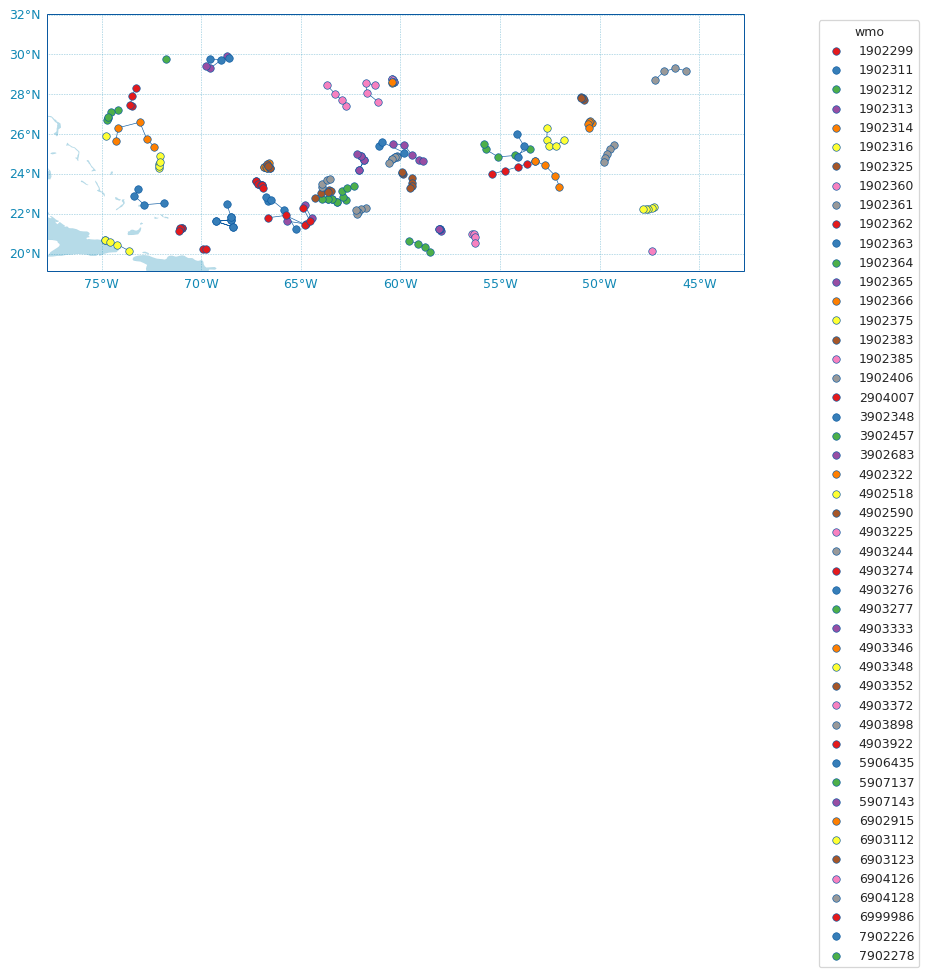

In [19]:
fetcher.plot()

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

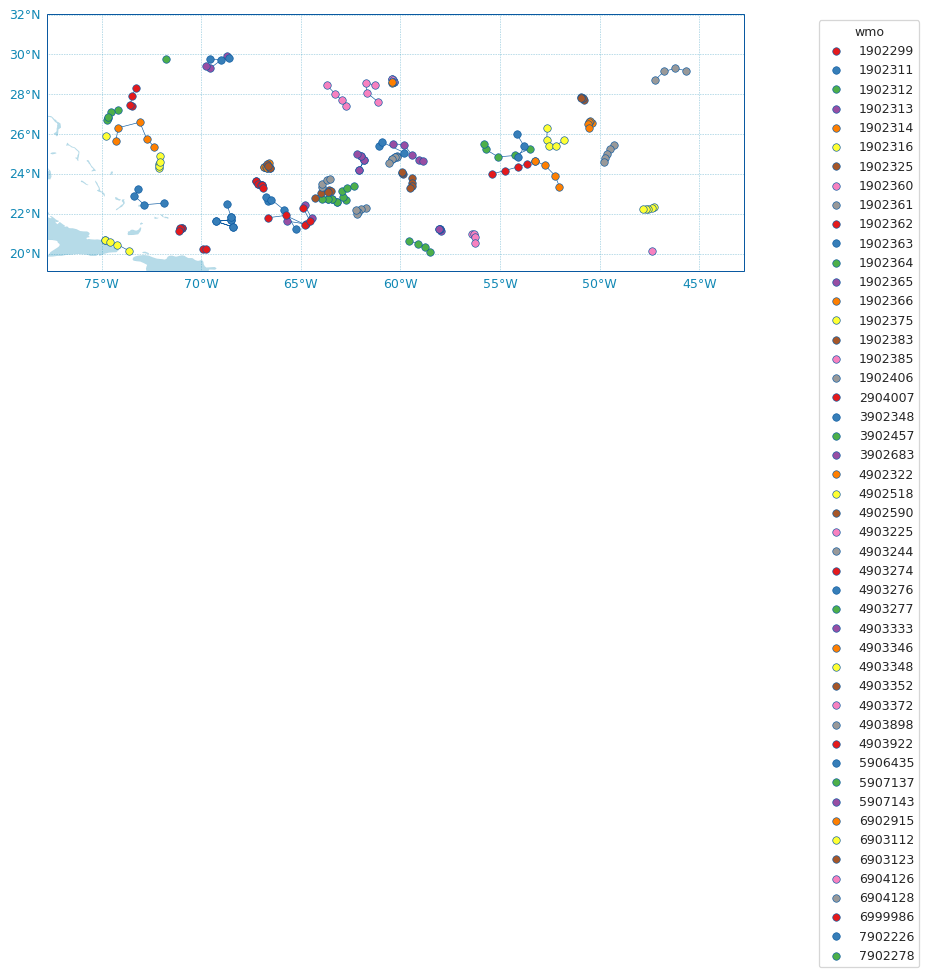

In [20]:
fetcher.plot('trajectory')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

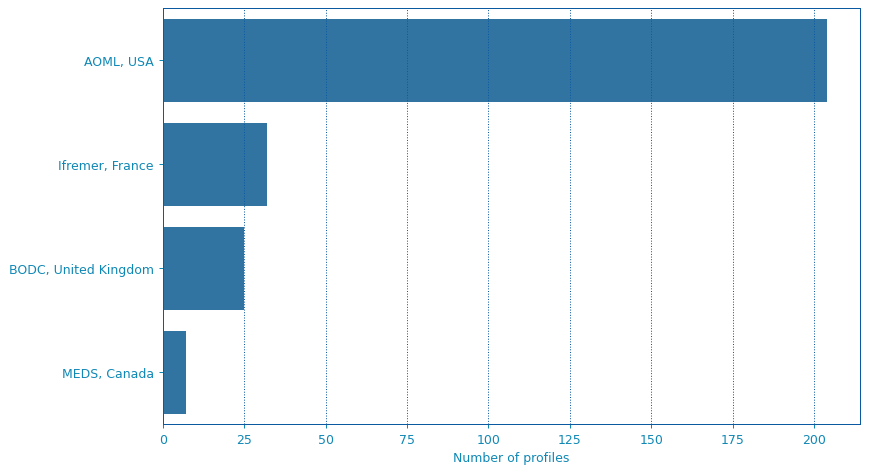

In [21]:
fetcher.plot('dac')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

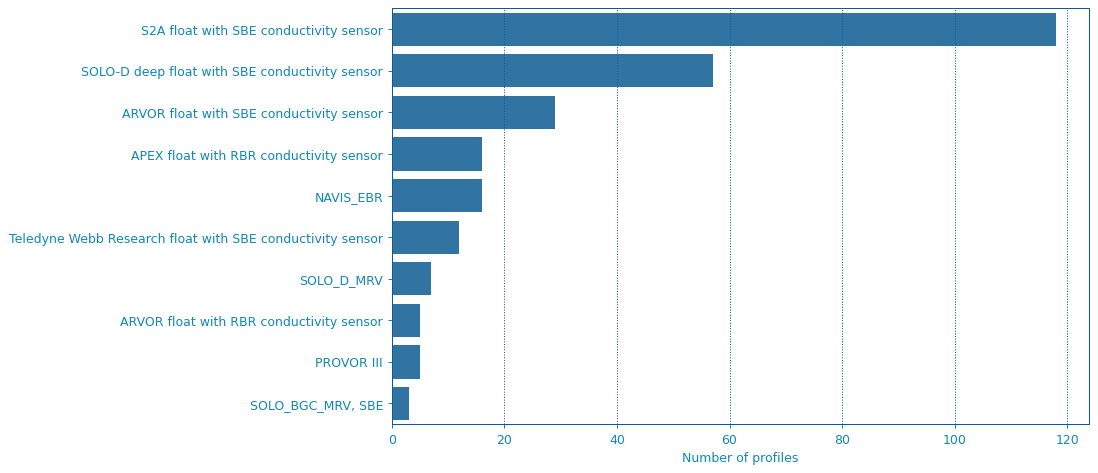

In [22]:
fetcher.plot('profiler')


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x1777982d0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x14ec002d0>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x35ef15b50>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x16ca7d050>})

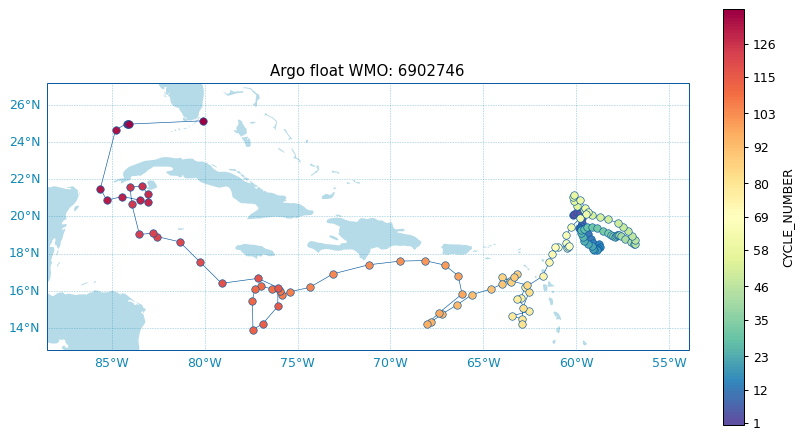

In [23]:
# ArgoFloat
from argopy import ArgoFloat
af = ArgoFloat(6902746)
af.plot.trajectory()


/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2650: RuntimeWarning: invalid value encountered in cast
  output[index] = result


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x35ee101d0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x177720050>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x35eb077d0>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x35eebde90>})

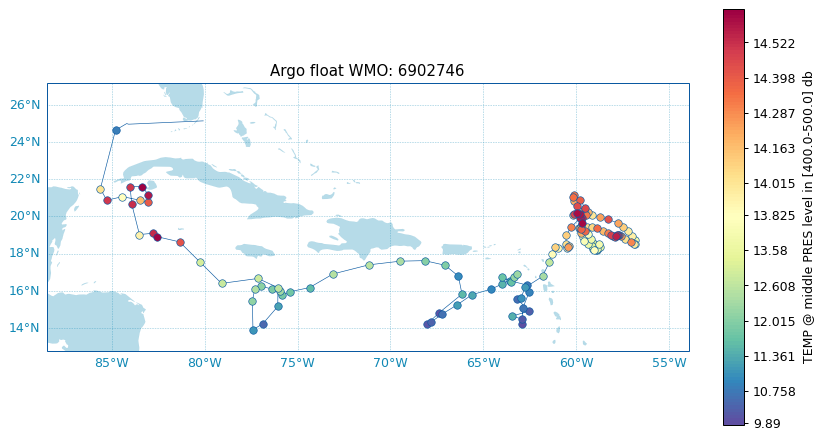

In [24]:
af.plot.map('TEMP', pres=450)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x35f0d4e10>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x35f6bc8d0>,
  'traj': [<matplotlib.lines.Line2D at 0x35f6ee210>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x35ef47850>})

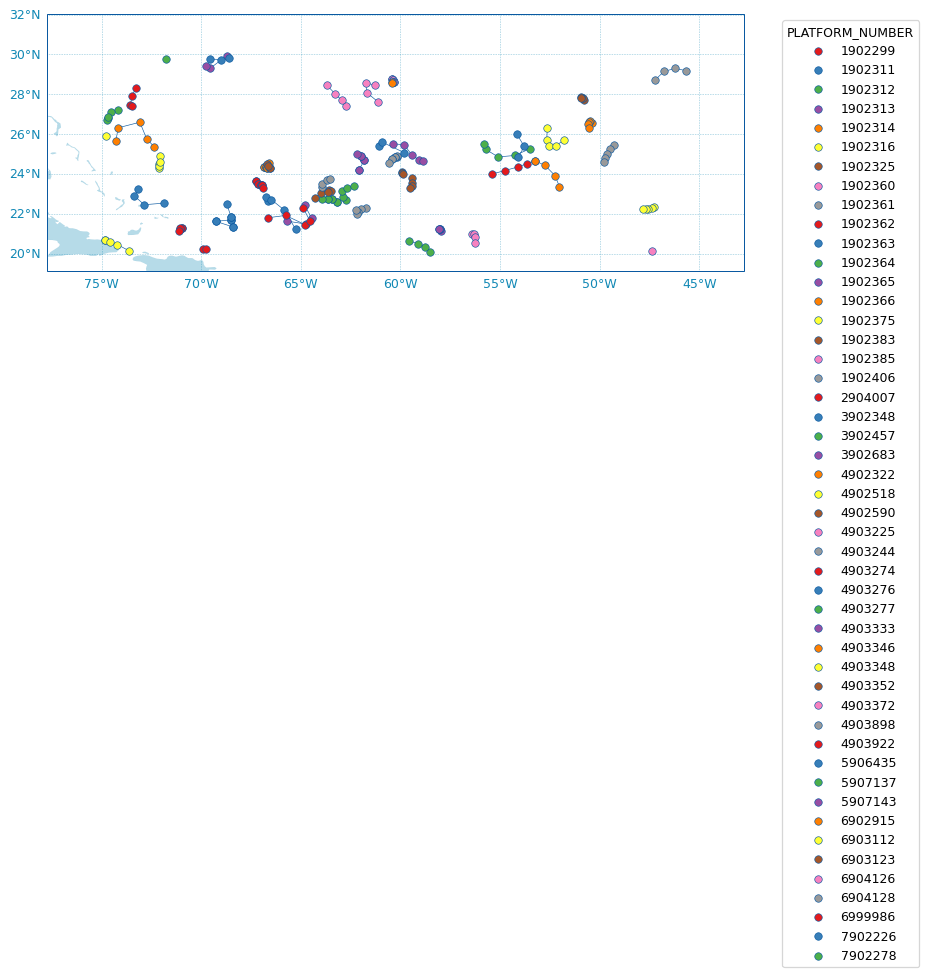

In [25]:
from argopy.plot import scatter_map
ds = fetcher.data.argo.point2profile()
scatter_map(ds)
